In [1]:
!pip install datasets

import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
from transformers import Trainer

In [2]:
model_name = "roberta-base"
model = AutoModelForSequenceClassification.from_pretrained("roberta")
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
df = pd.read_csv('tracks_labeled_both.csv', sep=";")

In [4]:
df["label_name"].value_counts()

,count
label_name,
fear,35
anger,29
sadness,21
disgust,13
surprise,10
joy,6


In [5]:
emotions = ['fear', 'sadness', 'surprise', 'anger', 'joy', 'disgust']
label2id = {'fear': 0, 'sadness': 1, 'anger': 2, 'disgust': 3, 'joy': 4, 'surprise': 5}
id2label = {0: 'fear', 1: 'sadness', 2: 'anger', 3: 'disgust', 4: 'joy', 5: 'surprise'}

df["label"] = df["label_name"].map(label2id)

In [6]:
def tokenize_function(examples):
    return tokenizer(examples["lyrics"], padding="max_length", truncation=True, max_length=512)

In [7]:
test_dataset = Dataset.from_pandas(df)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/114 [00:00<?, ? examples/s]

In [8]:
trainer = Trainer(model=model, tokenizer=tokenizer)
preds = trainer.predict(test_dataset)
predicted_ids = np.argmax(preds.predictions, axis=1)


<ipython-input-8-934dd9b4554d>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: myelman17 (myelman17-y-ld-z-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [9]:
from sklearn.metrics import classification_report
y_pred = np.argmax(preds.predictions, axis = 1)
y_true = test_dataset[:]['label']

print(classification_report(y_true, y_pred, target_names=emotions))

              precision    recall  f1-score   support

        fear       0.74      0.74      0.74        35
     sadness       0.88      0.67      0.76        21
    surprise       0.85      0.79      0.82        29
       anger       0.53      0.77      0.62        13
         joy       1.00      0.50      0.67         6
     disgust       0.50      0.70      0.58        10

    accuracy                           0.73       114
   macro avg       0.75      0.70      0.70       114
weighted avg       0.76      0.73      0.73       114



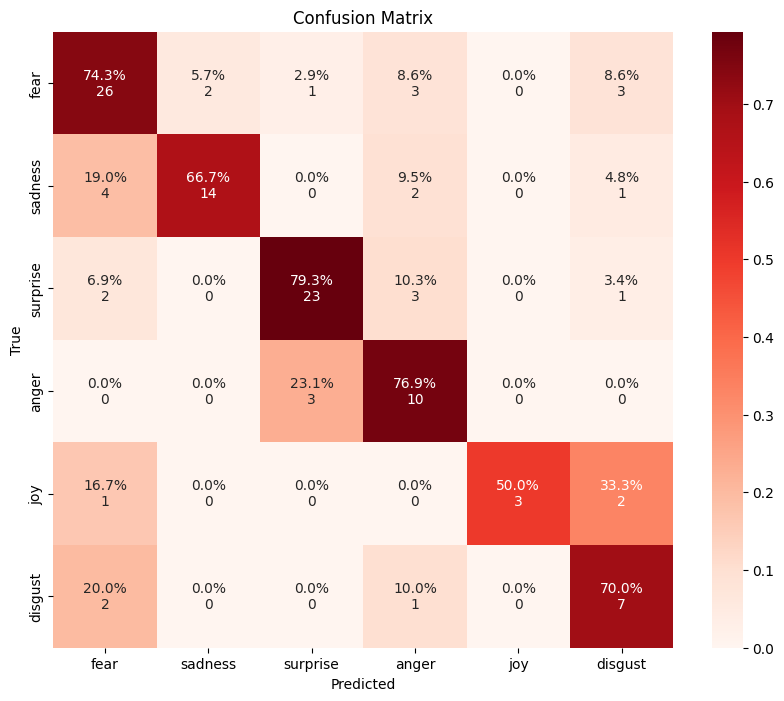

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix (sayısal)
cm = confusion_matrix(y_true, y_pred)

# Oransal (normalize)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Etiketler: yüzde + sayı
labels = np.array([
    [f"{cm_normalized[i, j]*100:.1f}%\n{cm[i, j]}" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

# Grafik çizimi
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Reds", xticklabels=emotions, yticklabels=emotions)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()